In [ ]:
path="C:/Users/USER/Documents/Trabajo/Text oritation/SROIE_2019_text_recognition"

import os
import pandas as pd
import random 
from PIL import Image
data=[]
path_csv="C:/Users/USER/Documents/Trabajo/Text oritation/data.csv"
if not os.path.exists(path):
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".jpg"):
                file_path = os.path.join(root, file)
                angle = random.randint(0, 359)
                img= Image.open(file_path).convert("RGB").rotate(angle, expand=True) 
                data.append({"path":file_path,"filename":file,"imagen":img,"angle":angle,"type":os.path.basename(root)})
    df = pd.DataFrame(data)
    df.to_csv("data.csv")
else:
    df = pd.read_csv(path_csv)





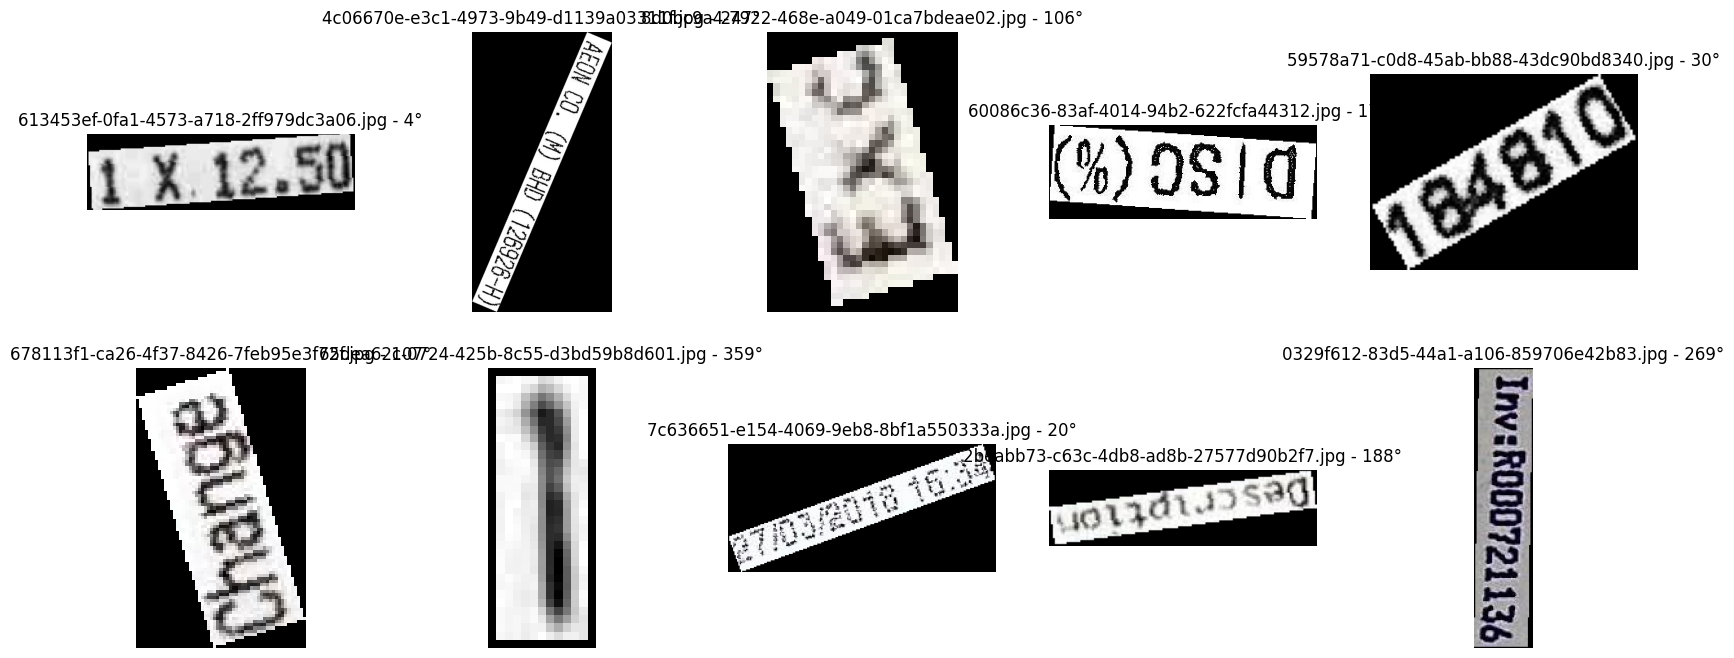

In [19]:
import matplotlib.pyplot as plt
df_sample = df.sample(n=10, random_state=42)  # 10% sample
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, (_, row) in zip(axes.flatten(), df_sample.iterrows()):
    ax.imshow(row['imagen'])
    ax.set_title(f"{row['filename']} - {row['angle']}°")
    ax.axis('off')

In [26]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
import lightning as L
from sklearn.model_selection import train_test_split, KFold
from torchvision import transforms, models
import numpy as np


class ImageKitAngleDataset(Dataset):
    def __init__(self, images):
        self.images = images
        self.transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),  # Tamaño requerido por EfficientNet_B0
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        efficientnet = models.mobilenet_v2(
            weights="IMAGENET1K_V2"
        )  # Usar MobileNetV2 como alternativa ligera
        self.feature_extractor = nn.Sequential(
            efficientnet.features,
            nn.AdaptiveAvgPool2d((1, 1)),  # Reduce a [batch, 1280, 1, 1]
        )
        self.feature_extractor.eval()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img_tensor = self.transform(img).unsqueeze(0)  # [1, 3, 224, 224]
        with torch.no_grad():
            features = self.feature_extractor(img_tensor).view(-1)  # → [1280]
        return features


class MyDataModule(L.LightningDataModule):
    def __init__(self, df, batch_size=64, kfold=5):
        super().__init__()
        self.df = df
        self.batch_size = batch_size
        self.kfold = kfold
        self.image_dataset = ImageKitAngleDataset(df["imagen"].tolist())
        self.angles = df["angle"].values.astype(np.float32)
        angles_rad = np.deg2rad(self.angles)
        self.y = torch.tensor(
            np.stack([np.sin(angles_rad), np.cos(angles_rad)], axis=1),
            dtype=torch.float32,
        )

    def prepare_data(self):
        self.X_train_idx, self.X_test_idx, self.y_train, self.y_test = train_test_split(
            np.arange(len(self.df)),
            self.y,
            test_size=0.3,
            shuffle=True,
            random_state=42,
        )
        self.kfolder = list(
            KFold(n_splits=self.kfold, shuffle=True, random_state=42).split(
                self.X_train_idx
            )
        )

    def setup(self, stage=None, n_fold=0):
        if stage == "fit" or stage is None:
            train_idx, val_idx = self.kfolder[n_fold]
            train_idx = self.X_train_idx[train_idx]
            val_idx = self.X_train_idx[val_idx]
            self.train_dataset = torch.utils.data.TensorDataset(
                torch.stack([self.image_dataset[i] for i in train_idx]),
                self.y[train_idx],
            )
            self.val_dataset = torch.utils.data.TensorDataset(
                torch.stack([self.image_dataset[i] for i in val_idx]), self.y[val_idx]
            )

        if stage == "test" or stage is None:
            self.test_dataset = torch.utils.data.TensorDataset(
                torch.stack([self.image_dataset[i] for i in self.X_test_idx]),
                self.y[self.X_test_idx],
            )

        if stage == "predict" or stage is None:
            self.predict_dataset = self.test_dataset

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self, data=None):
        if data is None:
            return DataLoader(
                self.predict_dataset, batch_size=self.batch_size, shuffle=False
            )
        else:
            return DataLoader(data, batch_size=self.batch_size, shuffle=False)

In [ ]:
dataset=MyDataModule(df=df,batch_size=64,kfold=5)
dataset.prepare_data()
dataset.setup()


In [ ]:
import torch
import torch.nn as nn
import lightning as L


class MobileNetV2AngleRegressor(L.LightningModule):
    def __init__(
        self, input_dim=1280, lr=1e-4, lambda_reg=0.0001, regularization=None, hidden_units=[16, 16, 16]
    ):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.regularization = regularization
        self.lambda_reg = lambda_reg

        layers = [nn.Flatten()]
        in_features = input_dim
        for units in hidden_units:
            layers.append(nn.Linear(in_features, units))
            nn.LayerNorm(units)
            layers.append(nn.LeakyReLU(negative_slope=0.1))
            in_features = units

        layers.append(nn.Linear(in_features, 2))  # → [sin(θ), cos(θ)]
        self.backbone = nn.Sequential(*layers)

        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.backbone(x)

    def configure_optimizers(self):
        if self.regularization == "L2":
            return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.lambda_reg)
        else:
            return torch.optim.Adam(self.parameters(), lr=self.lr)

    def compute_regularization_loss(self):
        reg_loss = 0.0
        if self.regularization == "L1":
            for param in self.parameters():
                reg_loss += torch.sum(torch.abs(param))
        elif self.regularization == "L2":
            for param in self.parameters():
                reg_loss += torch.sum(param ** 2)
        return self.lambda_reg * reg_loss

    def angle_error_degrees(self, y_hat, y):
        angle_pred = torch.atan2(y_hat[:, 0], y_hat[:, 1]) * (180 / torch.pi)
        angle_true = torch.atan2(y[:, 0], y[:, 1]) * (180 / torch.pi)
        error = torch.abs(angle_pred - angle_true) % 360
        error = torch.where(error > 180, 360 - error, error)
        return error.mean()

    def training_step(self, batch, batch_idx):
        x, y = batch  # y: [batch, 2] → [sin(θ), cos(θ)]
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y.float())
        if self.regularization in ["L1", "L2"]:
            loss += self.compute_regularization_loss()

        angle_err_deg = self.angle_error_degrees(y_hat, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True)
        self.log("train_angle_error_deg", angle_err_deg, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y.float())
        angle_err_deg = self.angle_error_degrees(y_hat, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_angle_error_deg", angle_err_deg, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y.float())
        angle_err_deg = self.angle_error_degrees(y_hat, y)
        self.log("test_loss", loss, on_epoch=True)
        self.log("test_angle_error_deg", angle_err_deg, on_epoch=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x = batch
        preds = self(x)
        return preds


In [ ]:
lambda_ = 0.001
epochs = 1000  # Number of epochs for training
# hidden_units = [254, 254, 254]
# regul = "L1"
hiddens_units = [[64]*4,[128]*4,[256]*4,[512]*4]
reguls = ["L1", "L2"]

In [ ]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?|
#print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import os
import pandas as pd

df_metrics = pd.DataFrame()

regul = "L2"
for hidden_units in hiddens_units:
    results = []  # [losses]
    for i in range(dataset.kfold):
        model = MobileNetV2AngleRegressor(
            hidden_units=hidden_units,
            lambda_reg=lambda_,
            regularization=regul,
        )
        early_stop_callback = L.pytorch.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=10,
        )
        checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
            save_top_k=2,
            save_last=True,
            monitor="val_loss",
            mode="min",
        )
        callbacks = [early_stop_callback, checkpoint_callback]
        name = ",".join([str(n) for n in hidden_units])
        path = f"{name}_{regul}"
        fold_dir = os.path.join("checkpoints", path)
        os.makedirs(fold_dir, exist_ok=True)
        trainer = L.Trainer(
            max_epochs=epochs,
            callbacks=callbacks,
            accelerator="gpu" if device.type == "cuda" else "cpu",
            devices=1,
            default_root_dir=fold_dir,
        )
        dataset.setup(stage="fit", n_fold=i)
        trainer.fit(
            model,
            train_dataloaders=dataset.train_dataloader(),
            val_dataloaders=dataset.val_dataloader(),
        )
        result_val = trainer.validate(
            model,
            dataloaders=dataset.val_dataloader(),
            ckpt_path="best",
        )
        result_test = trainer.test(
            model,
            dataloaders=dataset.test_dataloader(),
            ckpt_path="best",
        )
        print(result_test)
        results.append(result_test[0]["test_angle_error_deg"])
    # Agregar columnas al DataFrame
    col_loss = f"{name}_{regul}_loss_deg"
    df_metrics[col_loss] = results